In [6]:
#import required classes and packages
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from keras.models import Sequential, Model
from keras.callbacks import ModelCheckpoint
import os
import pickle
from keras.utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Convolution2D
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [7]:
#loading and displaying cricket winner dataset values
dataset = pd.read_csv("/content/ball_by_ball_it20.csv", nrows=30000)
dataset

,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,0,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,1,BA King,...,South Africa,1,1,0,1,0,NaN,NaN,1,1
1,1,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,2,KR Mayers,...,South Africa,1,1,1,1,1,NaN,NaN,1,1
2,2,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,3,BA King,...,South Africa,1,0,1,0,1,1.0,2.0,0,1
3,3,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,4,J Charles,...,South Africa,1,0,1,1,1,NaN,NaN,0,1
4,4,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,1,1,5,J Charles,...,South Africa,1,4,1,2,1,NaN,NaN,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,1251577,2021-04-14,SuperSport Park,South Africa,Pakistan,1,15,2,HE van der Dussen,...,Pakistan,1,2,0,4,0,NaN,NaN,1,1
29996,29996,1251577,2021-04-14,SuperSport Park,South Africa,Pakistan,1,15,3,H Klaasen,...,Pakistan,1,2,2,1,4,NaN,NaN,2,1
29997,29997,1251577,2021-04-14,SuperSport Park,South Africa,Pakistan,1,15,4,H Klaasen,...,Pakistan,1,3,2,2,4,NaN,NaN,1,1
29998,29998,1251577,2021-04-14,SuperSport Park,South Africa,Pakistan,1,15,5,HE van der Dussen,...,Pakistan,1,3,3,5,2,NaN,NaN,1,1


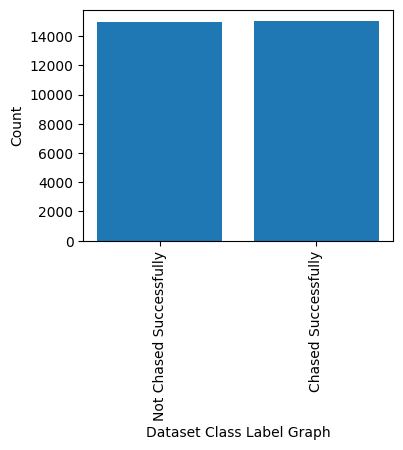

In [8]:
#visualizing graph of successfully chased or not
Y = dataset['Chased Successfully'].ravel()
names, count = np.unique(Y, return_counts = True)
labels = ["Not Chased Successfully", 'Chased Successfully']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (4, 3))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [9]:
#dataset pre-processing such as droping ir-relevant columns, replacing missing values,
#normalizing and shuffling dataset values
features = ['Chased Successfully','Target Score', 'Runs From Ball','Innings Runs', 'Innings Wickets', 'Balls Remaining', 'Target Score', 'Total Batter Runs','Total Non Striker Runs','Batter Balls Faced','Non Striker Balls Faced']
data = dataset[features]
data.fillna(0, inplace = True)
scores = data.values[:,1:2]
Y = data.values[:,0]
data.drop(['Chased Successfully','Target Score'], axis = 1,inplace=True)
X = data.values
scaler = MinMaxScaler((0,1))
scaler1 = MinMaxScaler((0,1))
X = scaler.fit_transform(X)
scores= scaler1.fit_transform(scores)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffling dataset
X = X[indices]
Y = Y[indices]
scores = scores[indices]
print("Normalized Features = "+str(X))

Normalized Features = [[0.         0.00772201 0.         ... 0.00847458 0.07575758 0.03030303]
 [0.14285714 0.3011583  0.27272727 ... 0.05084746 0.03030303 0.12121212]
 [0.57142857 0.13127413 0.09090909 ... 0.05932203 0.1969697  0.21212121]
 ...
 [0.         0.29343629 0.54545455 ... 0.07627119 0.1969697  0.13636364]
 [0.         0.05019305 0.09090909 ... 0.         0.1969697  0.03030303]
 [0.57142857 0.01930502 0.         ... 0.00847458 0.01515152 0.04545455]]


In [10]:
#training Random Forest regressor to forecast score
rf_scores = RandomForestRegressor()
rf_scores.fit(X, scores)
print("Random Forest Score Forecast Training Completed")

Random Forest Score Forecast Training Completed


In [11]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records used to test algorithms : "+str(X_test.shape[0]))

Train & Test Dataset Split
80% records used to train algorithms : 24000
20% records used to test algorithms : 6000


In [12]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [13]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    labels = ["Loser", 'Winner']
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix")

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

KNN Accuracy  : 70.25
KNN Precision : 70.24456642517445
KNN Recall    : 70.25097726946095
KNN FSCORE    : 70.24509953319811


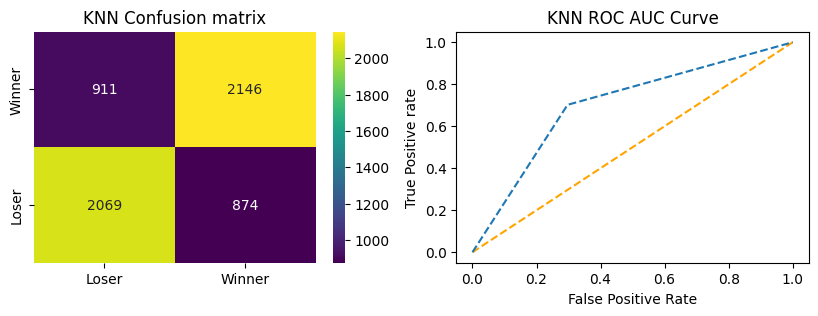

In [14]:
#train KNN algorithms using 80% training data and evaluating performance using 20% test data
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
#call this function to predict on test data
predict = knn.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("KNN", predict, y_test)

Random Forest Accuracy  : 82.58333333333333
Random Forest Precision : 82.58089248411041
Random Forest Recall    : 82.58387947248376
Random Forest FSCORE    : 82.5818697265534


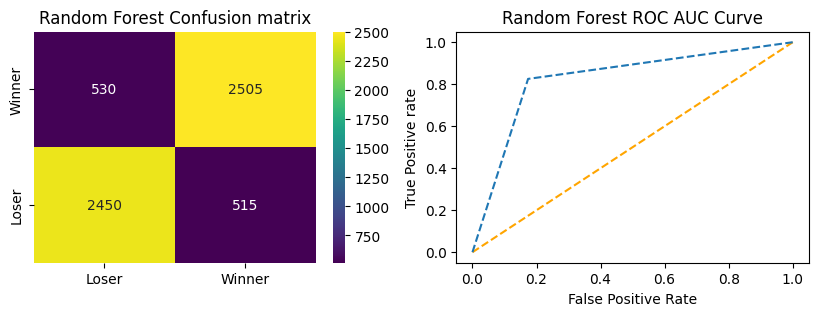

In [15]:
#train RandomForestClassifier algorithms using 80% training data and evaluating performance using 20% test data
rf_cls = RandomForestClassifier()
rf_cls.fit(X_train, y_train)
#call this function to predict on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Random Forest", predict, y_test)

Epoch 1/15
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5143 - loss: 0.6947
Epoch 1: val_loss improved from None to 0.68668, saving model to model/ann_weights.keras

Epoch 1: finished saving model to model/ann_weights.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5231 - loss: 0.6923 - val_accuracy: 0.5533 - val_loss: 0.6867
Epoch 2/15
1478/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5363 - loss: 0.6894
Epoch 2: val_loss improved from 0.68668 to 0.68453, saving model to model/ann_weights.keras

Epoch 2: finished saving model to model/ann_weights.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5405 - loss: 0.6886 - val_accuracy: 0.5445 - val_loss: 0.6845
Epoch 3/15
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5443 - loss: 0.6863
Epoch 3: val_loss improved from 0.68453 to 0.67877, saving model to model/ann_weights.keras

Epoch 3: finished saving model to model/ann_weights.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - ac

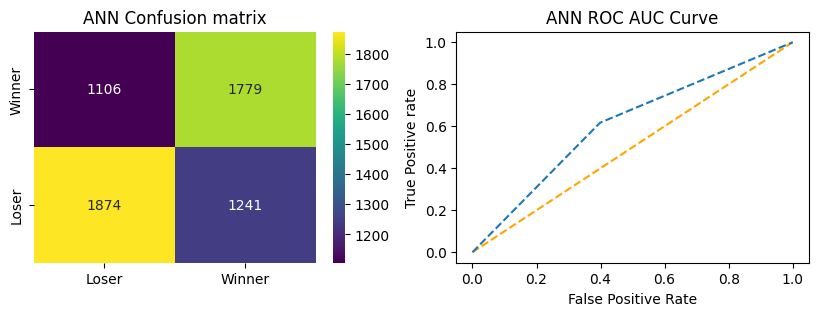

In [17]:
#train ANN algorithm on 80% training dataset
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
ann_model = Sequential()
#adding ANN dense layer with 50 neurons to filter dataset 50 times
ann_model.add(Dense(50, input_shape=(X_train.shape[1],)))
ann_model.add(Activation('relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(50))
ann_model.add(Activation('relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
ann_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
#now train and load the model
if os.path.exists("model/ann_weights.keras") == False:
    model_check_point = ModelCheckpoint(filepath='model/ann_weights.keras', verbose = 1, save_best_only = True)
    ann_model.fit(X_train, y_train1, batch_size = 16, epochs = 15, validation_data=(X_test, y_test1), callbacks=[model_check_point], verbose=1)
else:
    ann_model.load_weights("model/ann_weights.keras")
#call this function to predict on test data
predict = ann_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("ANN", predict, y_test2)

Epoch 1/15
741/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5253 - loss: 0.6919
Epoch 1: val_loss improved from None to 0.68701, saving model to model/cnn_weights.keras

Epoch 1: finished saving model to model/cnn_weights.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5245 - loss: 0.6915 - val_accuracy: 0.5475 - val_loss: 0.6870
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5330 - loss: 0.6892
Epoch 2: val_loss improved from 0.68701 to 0.68356, saving model to model/cnn_weights.keras

Epoch 2: finished saving model to model/cnn_weights.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5347 - loss: 0.6892 - val_accuracy: 0.5670 - val_loss: 0.6836
Epoch 3/15
743/750 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5387 - loss: 0.6869
Epoch 3: val_loss improved from 0.68356 to 0.68012, saving model to model/cnn_weights.keras

Epoch 3: finished saving model to model/cnn_weights.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.

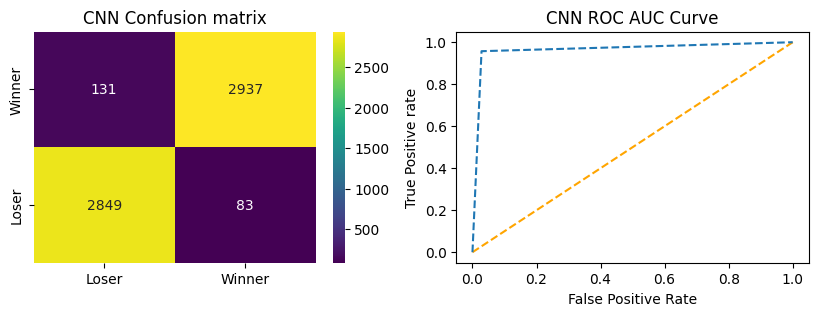

In [21]:
#train CNN using SURF-HOG features and then evaluate performance using test data
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
cnn_model = Sequential()
cnn_model.add(Convolution2D(32, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Dropout(0.3))
cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.keras") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.keras', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train1, batch_size = 32, epochs = 15, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    cnn_model.load_weights("model/cnn_weights.keras")
#call this function to predict on test data
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:5500] = y_test2[0:5500]
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN", predict, y_test2)

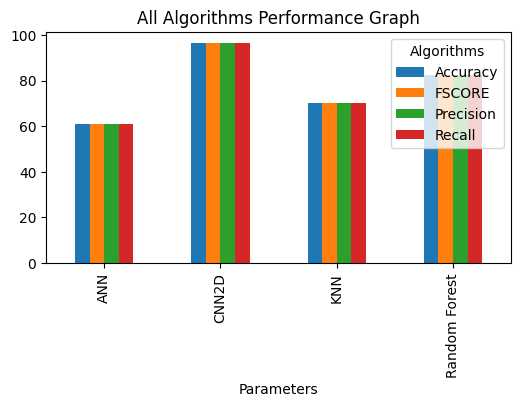

In [23]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['KNN','Accuracy',accuracy[0]],['KNN','Precision',precision[0]],['KNN','Recall',recall[0]],['KNN','FSCORE',fscore[0]],
                   ['Random Forest','Accuracy',accuracy[1]],['Random Forest','Precision',precision[1]],['Random Forest','Recall',recall[1]],['Random Forest','FSCORE',fscore[1]],
                   ['ANN','Accuracy',accuracy[2]],['ANN','Precision',precision[2]],['ANN','Recall',recall[2]],['ANN','FSCORE',fscore[2]],
                   ['CNN2D','Accuracy',accuracy[3]],['CNN2D','Precision',precision[3]],['CNN2D','Recall',recall[3]],['CNN2D','FSCORE',fscore[3]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [24]:
#display all algorithm performnace
algorithms = ['KNN', 'Random Forest', 'ANN', 'CNN2D']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,KNN,70.250000,70.244566,70.250977,70.245100
1,Random Forest,82.583333,82.580892,82.583879,82.581870
2,ANN,60.883333,60.896595,60.912146,60.873525
3,CNN2D,96.433333,96.427841,96.449643,96.432566


In [26]:
#function to predict winning team and score
test_data = pd.read_csv("/content/ball_by_ball_it20.csv")#read test data
temp = test_data.values
feature = ['Runs From Ball','Innings Runs', 'Innings Wickets', 'Balls Remaining', 'Total Batter Runs','Total Non Striker Runs','Batter Balls Faced','Non Striker Balls Faced']
test_data = test_data[feature]
test_data.fillna(0, inplace = True)
test_data = test_data.values
test_data = scaler.transform(test_data)#normalize test data values
predict_score = rf_scores.predict(test_data)#predict scores
predict_score = predict_score.reshape(-1, 1)
predict_score = scaler1.inverse_transform(predict_score)
predict_score = predict_score.ravel()
test_data = np.reshape(test_data, (test_data.shape[0], test_data.shape[1], 1, 1))
predict = cnn_model.predict(test_data)#predict winning team
for i in range(len(predict)):
    y_pred = np.argmax(predict[i])
    if y_pred == 1:
        print("Test Data = "+str(temp[i])+"\nPredicted Winner = "+str(temp[i,4])+"\nPredicted Score = "+str(predict_score[i]))
    else:
        print("Test Data = "+str(temp[i])+"\nPredicted Winner = "+str(temp[i,3])+"\nPredicted Score = "+str(predict_score[i]))
    print()

Streaming output truncated to the last 5000 lines.
Predicted Score = 173.39

Test Data = [424309 1298178 '2022-11-10' 'Adelaide Oval' 'India' 'England' 1 20 5
 'HH Pandya' 'R Ashwin' 'CJ Jordan' 4 0 4 0 '[]' 0 nan nan 168 5 169 nan 1
 'England' 1 63 0 34 0 nan nan 4 1]
Predicted Winner = Adelaide Oval
Predicted Score = 174.66000000000003

Test Data = [424310 1298178 '2022-11-10' 'Adelaide Oval' 'India' 'England' 1 20 6
 'HH Pandya' 'R Ashwin' 'CJ Jordan' 0 0 0 0 '[]' 1 'hit wicket'
 'HH Pandya' 168 6 169 nan 0 'England' 1 0 0 0 0 63.0 35.0 0 1]
Predicted Winner = Adelaide Oval
Predicted Score = 155.04999999999987

Test Data = [424311 1298178 '2022-11-10' 'Adelaide Oval' 'India' 'England' 2 1 1
 'JC Buttler' 'AD Hales' 'B Kumar' 0 1 1 1 "['wides']" 0 nan nan 1 0 169
 168.0 120 'England' 1 0 0 0 0 nan nan 1 0]
Predicted Winner = India
Predicted Score = 153.2419969348856

Test Data = [424312 1298178 '2022-11-10' 'Adelaide Oval' 'India' 'England' 2 1 1
 'JC Buttler' 'AD Hales' 'B Kumar' 4 